# Notebook Hyperparameter Tuning BERTopic vs LDA

Notebook ini dipakai untuk eksperimen tuning parameter secara terkontrol di environment fastAPI yang sama dengan aplikasi utama.

## 1. Setup Environment dan Import Library
Import library utama, atur random seed, dan tetapkan path kerja agar artefak tuning tersimpan konsisten.

Setup environment lokal (tanpa remote container):
```bash
cd fastapi
bash scripts/setup_local_notebook_env.sh
```
Catatan: script akan memprioritaskan `python3.11`. Jika tidak ada, script fallback ke `python3` dengan warning mismatch versi.

In [5]:
import itertools
import json
import os
import random
import sys
import time
from datetime import datetime
from importlib import metadata as importlib_metadata
from pathlib import Path

# Hindari warning permission matplotlib saat kernel jalan di container/non-root.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

CWD = Path.cwd()
if (CWD / "app").exists():
    FASTAPI_ROOT = CWD
elif (CWD.parent / "app").exists():
    FASTAPI_ROOT = CWD.parent
else:
    raise RuntimeError("Jalankan notebook dari folder fastapi atau subfolder di dalamnya.")

if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

ARTIFACTS_DIR = FASTAPI_ROOT / "data" / "results" / "artifacts_tuning"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

from gensim.corpora import Dictionary
from IPython.display import display

from app.ml.bertopic_trainer import BERTopicTrainer
from app.ml.evaluator import TopicEvaluator
from app.ml.hyperparameters import BERTOPIC_GRID, BERTOPIC_PRESETS, LDA_GRID, LDA_PRESETS
from app.ml.lda_trainer import LDATrainer
from app.models.schemas import BERTopicHyperparameters, HDBSCANHyperparameters, LDAHyperparameters, UMAPHyperparameters
from app.services.preprocessing import TextPreprocessor

pd.set_option("display.max_columns", 200)
print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("PYTHON_EXECUTABLE:", sys.executable)
print("PYTHON_VERSION:", sys.version.split()[0])

expected_python = (3, 11)
if sys.version_info[:2] != expected_python:
    print(f"WARNING: Disarankan Python {expected_python[0]}.{expected_python[1]} agar hasil konsisten dengan FastAPI container.")

expected_versions = {
    "torch": "2.11.0+cpu",
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "bertopic": "0.16.4",
    "sentence-transformers": "3.3.1",
    "hdbscan": "0.8.40",
    "umap-learn": "0.5.7",
    "gensim": "4.3.3",
}

version_mismatch = []
for package_name, expected_version in expected_versions.items():
    try:
        installed_version = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        version_mismatch.append((package_name, expected_version, "not-installed"))
        continue

    if installed_version != expected_version:
        version_mismatch.append((package_name, expected_version, installed_version))

if version_mismatch:
    print("WARNING: Ada versi paket yang tidak sama dengan environment FastAPI container:")
    for pkg, expected, installed in version_mismatch:
        print(f"- {pkg}: expected={expected}, installed={installed}")
else:
    print("Versi Python & paket utama sudah selaras dengan FastAPI container.")

FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
ARTIFACTS_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/artifacts_tuning
PYTHON_EXECUTABLE: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/.venv-fastapi-notebook/bin/python
PYTHON_VERSION: 3.12.3
Versi Python & paket utama sudah selaras dengan FastAPI container.


## 2. Load Dataset, Normalisasi Kolom Raw, dan Validasi Skema Teks
Muat dataset dari local file, normalisasi nama kolom raw (mis. `Judul` -> `title`, `Abstrak` -> `abstract`, `Kesimpulan` -> `conclusion`), bersihkan teks dasar, lalu tampilkan statistik awal.

In [6]:
DATA_SOURCE_CANDIDATES = [
    FASTAPI_ROOT / "data" / "processed" / "preprocessed_data.csv",
    FASTAPI_ROOT / "data" / "processed" / "processed_data.csv",
    FASTAPI_ROOT / "data" / "processed" / "topic_model_dataset.csv",
]
RAW_DATA_PATH = FASTAPI_ROOT / "data" / "raw" / "raw_data.csv"


def load_source_dataframe():
    for candidate in DATA_SOURCE_CANDIDATES:
        if candidate.exists():
            print(f"Loaded processed data: {candidate}")
            return pd.read_csv(candidate), candidate

    if RAW_DATA_PATH.exists():
        print(f"Loaded raw data: {RAW_DATA_PATH}")
        return pd.read_csv(RAW_DATA_PATH), RAW_DATA_PATH

    raise FileNotFoundError("Tidak menemukan file data processed maupun raw_data.csv")


def normalize_raw_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    normalized_map = {}
    for col in df.columns:
        normalized = str(col).strip().lower()
        normalized = normalized.replace("%", "pct")
        normalized = "".join(ch if ch.isalnum() else "_" for ch in normalized)
        while "__" in normalized:
            normalized = normalized.replace("__", "_")
        normalized = normalized.strip("_")
        normalized_map[col] = normalized or "col"

    df = df.rename(columns=normalized_map)

    def coalesce(target_col: str, aliases: list[str]):
        existing = [c for c in aliases if c in df.columns]
        if not existing:
            return

        merged = pd.Series("", index=df.index, dtype="object")
        for col_name in existing:
            values = df[col_name].fillna("").astype(str).str.strip()
            empty_mask = merged.str.strip() == ""
            merged.loc[empty_mask] = values.loc[empty_mask]
        df[target_col] = merged

    coalesce("id", ["id"])
    coalesce("title", ["title", "judul"])
    coalesce("author", ["author", "penulis"])
    coalesce("year", ["year", "tahun"])
    coalesce("abstract", ["abstract", "abstrak"])
    coalesce("conclusion", ["conclusion", "kesimpulan"])
    coalesce("keywords", ["keywords", "kata_kunci"])
    coalesce("url", ["url"])

    for col_name in ["title", "abstract", "conclusion"]:
        if col_name in df.columns:
            df[col_name] = (
                df[col_name]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.replace(r"(?i)^(nan|none|null|tidak tersedia|-)$", "", regex=True)
                .str.strip()
            )

    if "year" in df.columns:
        df["year"] = (
            df["year"]
            .fillna("")
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
        )

    return df


source_df, source_path = load_source_dataframe()
source_df = normalize_raw_columns(source_df)

if "url" in source_df.columns:
    source_df = source_df.drop_duplicates(subset=["url"], keep="first")

text_candidates = ["combined_text", "cleaned_text", "processed_text", "abstract"]
text_col_for_validation = next((c for c in text_candidates if c in source_df.columns), None)
if text_col_for_validation is None:
    raise ValueError(
        "Dataset tidak punya kolom teks. Minimal salah satu dari: combined_text, cleaned_text, processed_text, abstract/abstrak"
    )

source_df[text_col_for_validation] = source_df[text_col_for_validation].fillna("").astype(str)
source_df[text_col_for_validation] = source_df[text_col_for_validation].str.replace(r"\s+", " ", regex=True).str.strip()

source_df = source_df[source_df[text_col_for_validation] != ""].copy()
source_df = source_df[source_df[text_col_for_validation].str.len() >= 30].copy()
source_df = source_df.drop_duplicates(subset=[text_col_for_validation]).reset_index(drop=True)

source_df["id"] = range(1, len(source_df) + 1)

if "year" in source_df.columns:
    source_df["year"] = pd.to_numeric(source_df["year"], errors="coerce").astype("Int64")

text_lengths = source_df[text_col_for_validation].str.split().apply(len)

summary_df = pd.DataFrame(
    {
        "metric": [
            "n_documents",
            "min_len",
            "mean_len",
            "median_len",
            "max_len",
        ],
        "value": [
            len(source_df),
            int(text_lengths.min()),
            round(float(text_lengths.mean()), 2),
            round(float(text_lengths.median()), 2),
            int(text_lengths.max()),
        ],
    }
)

print("Sumber data aktif:", source_path)
display(summary_df)

preview_cols = [c for c in ["id", "title", "year", "abstract", "conclusion"] if c in source_df.columns]
if preview_cols:
    display(source_df[preview_cols].head(3))
else:
    display(source_df.head(3))

Loaded raw data: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv
Sumber data aktif: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv


,metric,value
0,n_documents,473.00
1,min_len,54.00
2,mean_len,165.14
3,median_len,161.00
4,max_len,302.00


,id,title,year,abstract,conclusion
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan..."
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...


## 3. Preprocessing Teks Konsisten untuk BERTopic dan LDA
Bangun preprocessing reusable untuk menghasilkan corpus BERTopic (cleaned_text) dan corpus LDA (processed_text + dictionary/corpus). Jika input masih raw, notebook otomatis generate dua kolom tersebut dari title-abstract-conclusion yang sudah dinormalisasi.

In [7]:
preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)


def ensure_dual_preprocessing(df: pd.DataFrame):
    df = df.copy()

    # Bersihkan kolom teks dasar dulu untuk semua jalur input (processed maupun raw).
    for col_name in ["title", "abstract", "conclusion", "cleaned_text", "processed_text"]:
        if col_name in df.columns:
            df[col_name] = (
                df[col_name]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            )

    has_cleaned = "cleaned_text" in df.columns
    has_processed = "processed_text" in df.columns

    if has_cleaned and has_processed:
        df = df[(df["cleaned_text"] != "") & (df["processed_text"] != "")].reset_index(drop=True)
        return df, "existing_dual_columns"

    if "abstract" not in df.columns:
        raise ValueError(
            "Dataset raw belum punya kolom abstrak. Pastikan ada kolom `Abstrak` atau `abstract` sebelum preprocessing."
        )

    generated = preprocessor.preprocess_dataframe(
        df,
        text_column="abstract",
        title_column="title",
        conclusion_column="conclusion",
    )

    generated["cleaned_text"] = generated["cleaned_text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    generated["processed_text"] = generated["processed_text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    generated = generated[(generated["cleaned_text"] != "") & (generated["processed_text"] != "")].reset_index(drop=True)

    return generated, "generated_from_raw"


working_df, preprocessing_source = ensure_dual_preprocessing(source_df)

if "id" not in working_df.columns:
    working_df["id"] = range(1, len(working_df) + 1)
working_df["id"] = working_df["id"].astype(int)

if "year" in working_df.columns:
    working_df["year"] = pd.to_numeric(working_df["year"], errors="coerce").astype("Int64")

bertopic_docs = working_df["cleaned_text"].tolist()
lda_docs = working_df["processed_text"].tolist()

tokenized_lda_docs = [doc.split() for doc in lda_docs]
lda_dictionary = Dictionary(tokenized_lda_docs)
lda_corpus = [lda_dictionary.doc2bow(doc) for doc in tokenized_lda_docs]

if "year" in working_df.columns and working_df["year"].notna().all():
    timestamps = working_df["year"].astype(int).tolist()
else:
    timestamps = None

document_ids = working_df["id"].astype(int).tolist()

print("Preprocessing source:", preprocessing_source)
print("Jumlah dokumen BERTopic:", len(bertopic_docs))
print("Jumlah dokumen LDA:", len(lda_docs))
print("Ukuran dictionary LDA:", len(lda_dictionary))
print("Timestamps tersedia:", timestamps is not None)

preview_cols = [c for c in ["id", "title", "year", "cleaned_text", "processed_text"] if c in working_df.columns]
display(working_df[preview_cols].head(2))

2026-04-10 02:38:08.752 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-10 02:38:08.753 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...
2026-04-10 02:38:08.873 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-10 02:38:08.999 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-10 02:43:09.489 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-10 02:43:09.501 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-10 02:43:09.513 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Preprocessing source: generated_from_raw
Jumlah dokumen BERTopic: 473
Jumlah dokumen LDA: 473
Ukuran dictionary LDA: 5402
Timestamps tersedia: True


,id,title,year,cleaned_text,processed_text
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,"perbandingan metode grid search, random search...",banding grid search random search bayesian opt...
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,klasterisasi produktivitas pertanian di kabupa...,klasterisasi produktivitas tani kabupaten bata...


## 4. Definisi Search Space Hyperparameter BERTopic
Tetapkan skenario BERTopic dari preset dan/atau grid agar eksperimen bisa dilooping.

In [8]:
SCENARIO_MODE = "both"  # opsi: presets, grid, both
MAX_BERTOPIC_GRID_SCENARIOS = 6
SCENARIO_RANDOM_SEED = 42


def build_grid_combinations(grid_dict):
    keys = list(grid_dict.keys())
    value_lists = [grid_dict[k] for k in keys]
    return [dict(zip(keys, values)) for values in itertools.product(*value_lists)]


def sample_combinations(combos, max_items, seed):
    if max_items is None or max_items >= len(combos):
        return combos
    rng = random.Random(seed)
    return rng.sample(combos, k=max_items)


def bertopic_params_from_combo(combo):
    return BERTopicHyperparameters(
        embedding_model="denaya/indoSBERT-large",
        min_topic_size=combo["min_topic_size"],
        nr_topics=combo["nr_topics"],
        top_n_words=combo["top_n_words"],
        n_gram_range=list(combo["vectorizer_ngram_range"]),
        vectorizer_min_df=combo["vectorizer_min_df"],
        vectorizer_max_df=combo["vectorizer_max_df"],
        embedding_batch_size=16,
        seed=42,
        umap_params=UMAPHyperparameters(
            n_neighbors=combo["umap_n_neighbors"],
            n_components=combo["umap_n_components"],
            min_dist=combo["umap_min_dist"],
            metric=combo["umap_metric"],
            random_state=42,
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=combo["hdbscan_min_cluster_size"],
            min_samples=combo["hdbscan_min_samples"],
            cluster_selection_method=combo["hdbscan_cluster_selection_method"],
        ),
    )


bertopic_scenarios = []
all_bertopic_grid = []
sampled_bertopic_grid = []

if SCENARIO_MODE in {"presets", "both"}:
    for preset_name, preset_value in BERTOPIC_PRESETS.items():
        bertopic_scenarios.append(
            {
                "scenario_id": f"bertopic_preset_{preset_name}",
                "source": "preset",
                "params": preset_value.model_copy(deep=True),
                "meta": {"preset_name": preset_name},
            }
        )

if SCENARIO_MODE in {"grid", "both"}:
    all_bertopic_grid = build_grid_combinations(BERTOPIC_GRID)
    sampled_bertopic_grid = sample_combinations(all_bertopic_grid, MAX_BERTOPIC_GRID_SCENARIOS, SCENARIO_RANDOM_SEED)

    for idx, combo in enumerate(sampled_bertopic_grid, start=1):
        bertopic_scenarios.append(
            {
                "scenario_id": f"bertopic_grid_{idx:03d}",
                "source": "grid",
                "params": bertopic_params_from_combo(combo),
                "meta": combo,
            }
        )

print("BERTopic total scenarios:", len(bertopic_scenarios))
print("BERTopic total grid combinations:", len(all_bertopic_grid))

bertopic_preview = pd.DataFrame(
    [{"scenario_id": s["scenario_id"], "source": s["source"], "meta": str(s["meta"])} for s in bertopic_scenarios]
)
display(bertopic_preview.head(10))

BERTopic total scenarios: 9
BERTopic total grid combinations: 648


,scenario_id,source,meta
0,bertopic_preset_default,preset,{'preset_name': 'default'}
1,bertopic_preset_fine_grained,preset,{'preset_name': 'fine_grained'}
2,bertopic_preset_coarse,preset,{'preset_name': 'coarse'}
3,bertopic_grid_001,grid,"{'umap_n_neighbors': 40, 'umap_n_components': ..."
4,bertopic_grid_002,grid,"{'umap_n_neighbors': 40, 'umap_n_components': ..."
5,bertopic_grid_003,grid,"{'umap_n_neighbors': 55, 'umap_n_components': ..."
6,bertopic_grid_004,grid,"{'umap_n_neighbors': 55, 'umap_n_components': ..."
7,bertopic_grid_005,grid,"{'umap_n_neighbors': 55, 'umap_n_components': ..."
8,bertopic_grid_006,grid,"{'umap_n_neighbors': 40, 'umap_n_components': ..."


## 5. Definisi Search Space Hyperparameter LDA
Tetapkan skenario LDA yang sebanding agar perbandingan dengan BERTopic adil.

In [9]:
MAX_LDA_GRID_SCENARIOS = 12


def lda_params_from_combo(combo):
    return LDAHyperparameters(
        num_topics=combo["num_topics"],
        passes=combo["passes"],
        iterations=combo["iterations"],
        chunksize=100,
        random_state=42,
        alpha=combo["alpha"],
        eta=combo["eta"],
        no_below=combo["no_below"],
        no_above=combo["no_above"],
    )


lda_scenarios = []
all_lda_grid = []
sampled_lda_grid = []

if SCENARIO_MODE in {"presets", "both"}:
    for preset_name, preset_value in LDA_PRESETS.items():
        lda_scenarios.append(
            {
                "scenario_id": f"lda_preset_{preset_name}",
                "source": "preset",
                "params": preset_value.model_copy(deep=True),
                "meta": {"preset_name": preset_name},
            }
        )

if SCENARIO_MODE in {"grid", "both"}:
    all_lda_grid = build_grid_combinations(LDA_GRID)
    sampled_lda_grid = sample_combinations(all_lda_grid, MAX_LDA_GRID_SCENARIOS, SCENARIO_RANDOM_SEED)

    for idx, combo in enumerate(sampled_lda_grid, start=1):
        lda_scenarios.append(
            {
                "scenario_id": f"lda_grid_{idx:03d}",
                "source": "grid",
                "params": lda_params_from_combo(combo),
                "meta": combo,
            }
        )

print("LDA total scenarios:", len(lda_scenarios))
print("LDA total grid combinations:", len(all_lda_grid))

lda_preview = pd.DataFrame(
    [{"scenario_id": s["scenario_id"], "source": s["source"], "meta": str(s["meta"])} for s in lda_scenarios]
)
display(lda_preview.head(10))

LDA total scenarios: 15
LDA total grid combinations: 24


,scenario_id,source,meta
0,lda_preset_default,preset,{'preset_name': 'default'}
1,lda_preset_more_topics,preset,{'preset_name': 'more_topics'}
2,lda_preset_fewer_topics,preset,{'preset_name': 'fewer_topics'}
3,lda_grid_001,grid,"{'num_topics': 12, 'passes': 20, 'iterations':..."
4,lda_grid_002,grid,"{'num_topics': 8, 'passes': 10, 'iterations': ..."
5,lda_grid_003,grid,"{'num_topics': 8, 'passes': 10, 'iterations': ..."
6,lda_grid_004,grid,"{'num_topics': 10, 'passes': 10, 'iterations':..."
7,lda_grid_005,grid,"{'num_topics': 8, 'passes': 20, 'iterations': ..."
8,lda_grid_006,grid,"{'num_topics': 12, 'passes': 10, 'iterations':..."
9,lda_grid_007,grid,"{'num_topics': 8, 'passes': 20, 'iterations': ..."


## 6. Fungsi Evaluasi Topik (Coherence, Diversity, dan Runtime)
Buat evaluator terstandar agar hasil BERTopic dan LDA bisa dibandingkan di tabel yang sama.

In [10]:
evaluator = TopicEvaluator()


def safe_json_dumps(obj):
    return json.dumps(obj, ensure_ascii=False, default=str)


def evaluate_bertopic_run(trainer, docs, train_result):
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=docs,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )

    objective_score = float(metrics.get("score_cv_td", metrics.get("score", 0.0)) or 0.0)

    return {
        "coherence_cv": metrics.get("coherence_cv"),
        "topic_diversity": metrics.get("topic_diversity"),
        "objective_score": objective_score,
        "raw_score": metrics.get("score"),
        "score_cv_td": metrics.get("score_cv_td"),
        "score_hmean_cv_td": metrics.get("score_hmean_cv_td"),
        "num_topics": metrics.get("num_topics", train_result.get("num_topics")),
        "num_outliers": metrics.get("num_outliers", train_result.get("num_outliers")),
        "outlier_pct": metrics.get("outlier_pct"),
        "runtime_seconds": train_result.get("training_duration_seconds"),
    }


def evaluate_lda_run(trainer, train_result):
    metrics = evaluator.evaluate_lda(
        model=trainer.model,
        tokenized_docs=trainer.tokenized_docs,
        dictionary=trainer.dictionary,
    )

    objective_score = float(metrics.get("score", 0.0) or 0.0)

    return {
        "coherence_cv": metrics.get("coherence_cv"),
        "topic_diversity": metrics.get("topic_diversity"),
        "objective_score": objective_score,
        "raw_score": metrics.get("score"),
        "num_topics": metrics.get("num_topics", train_result.get("num_topics")),
        "runtime_seconds": train_result.get("training_duration_seconds"),
    }

## 7. Loop Hyperparameter Tuning untuk BERTopic
Jalankan seluruh skenario BERTopic, hitung metrik, tangani exception per eksperimen, lalu simpan hasil antar-run.

In [11]:
bertopic_rows = []
best_bertopic_payload = None
bertopic_started = time.time()
shared_embeddings = None

if bertopic_scenarios:
    print("Menghitung shared embeddings untuk semua skenario BERTopic...")
    embedding_trainer = BERTopicTrainer(params=bertopic_scenarios[0]["params"])
    shared_embeddings = embedding_trainer.compute_embeddings(bertopic_docs)
    print("Embeddings shape:", shared_embeddings.shape)

for idx, scenario in enumerate(bertopic_scenarios, start=1):
    scenario_id = scenario["scenario_id"]
    params = scenario["params"]

    print(f"[BERTopic {idx}/{len(bertopic_scenarios)}] {scenario_id}")

    row = {
        "model": "BERTopic",
        "scenario_id": scenario_id,
        "scenario_source": scenario["source"],
        "status": "ok",
    }

    try:
        trainer = BERTopicTrainer(params=params)
        train_result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=timestamps,
            document_ids=document_ids,
        )

        metrics_payload = evaluate_bertopic_run(trainer, bertopic_docs, train_result)

        row.update(metrics_payload)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])

        if (best_bertopic_payload is None) or (row["objective_score"] > best_bertopic_payload["objective_score"]):
            best_bertopic_payload = {
                "objective_score": row["objective_score"],
                "trainer": trainer,
                "scenario": scenario,
                "train_result": train_result,
                "metrics": metrics_payload,
            }

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])
        print("  gagal:", exc)

    bertopic_rows.append(row)

bertopic_results_df = pd.DataFrame(bertopic_rows)
if not bertopic_results_df.empty and "objective_score" in bertopic_results_df.columns:
    bertopic_results_df["objective_score"] = pd.to_numeric(bertopic_results_df["objective_score"], errors="coerce")
    bertopic_results_df = bertopic_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

bertopic_elapsed = time.time() - bertopic_started
print(f"BERTopic tuning selesai dalam {bertopic_elapsed / 60:.2f} menit")
display(bertopic_results_df.head(10))

2026-04-10 02:43:09.764 | INFO     | app.ml.bertopic_trainer:compute_embeddings:304 - Computing sentence embeddings for 473 documents using denaya/indoSBERT-large...
2026-04-10 02:43:09.765 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:145 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Menghitung shared embeddings untuk semua skenario BERTopic...


Batches: 100%|██████████| 30/30 [08:13<00:00, 16.45s/it]
2026-04-10 02:51:29.541 | INFO     | app.ml.bertopic_trainer:compute_embeddings:337 - Embeddings shape: (473, 256) (dim=256)
2026-04-10 02:51:29.550 | INFO     | app.ml.bertopic_trainer:train:359 - Starting BERTopic training on 473 documents
2026-04-10 02:51:29.551 | INFO     | app.ml.bertopic_trainer:train:360 - Embedding model: denaya/indoSBERT-large (256-dim)


Embeddings shape: (473, 256)
[BERTopic 1/9] bertopic_preset_default


2026-04-10 02:51:34.194 | INFO     | app.ml.bertopic_trainer:train:363 - Reproducibility settings applied with seed=42
2026-04-10 02:51:34.195 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:145 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-10 02:51:44.838 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-10 02:51:44.839 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-10 02:51:44,847 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-10 02:51:58,164 - BERTopic - Dimensionality - Completed ✓
2026-04-10 02:51:58,271 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-10 02:51:58,337 - BERTopic - Cluster - Completed ✓
2026-04-10 02:51:58,338 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-0

...

2026-04-10 03:38:14.685 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-10 03:38:14.686 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-10 03:38:14,689 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-10 03:38:15,743 - BERTopic - Dimensionality - Completed ✓
2026-04-10 03:38:15,744 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-10 03:38:15,761 - BERTopic - Cluster - Completed ✓
2026-04-10 03:38:15,761 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-10 03:39:04,306 - BERTopic - Representation - Completed ✓
2026-04-10 03:39:04,308 - BERTopic - Topic reduction - Reducing number of topics
2026-04-10 03:39:33,168 - BERTopic - Topic reduction - Reduced number of topics from 19 to 12
2026-04-10 03:39:33.334 | INFO     | app.ml.bertopic_trainer:train:390 - Ou

[BERTopic 9/9] bertopic_grid_006


2026-04-10 03:43:45.287 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-10 03:43:45.291 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-10 03:43:45,407 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-10 03:43:46,390 - BERTopic - Dimensionality - Completed ✓
2026-04-10 03:43:46,391 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-10 03:43:46,546 - BERTopic - Cluster - Completed ✓
2026-04-10 03:43:46,547 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-10 03:44:07,114 - BERTopic - Representation - Completed ✓
2026-04-10 03:44:07,115 - BERTopic - Topic reduction - Reducing number of topics
2026-04-10 03:44:26,123 - BERTopic - Topic reduction - Reduced number of topics from 8 to 8
2026-04-10 03:44:26.255 | INFO     | app.ml.bertopic_trainer:train:390 - Outl

BERTopic tuning selesai dalam 64.09 menit


,model,scenario_id,scenario_source,status,coherence_cv,topic_diversity,objective_score,raw_score,score_cv_td,score_hmean_cv_td,num_topics,num_outliers,outlier_pct,runtime_seconds,params,scenario_meta
0,BERTopic,bertopic_grid_003,grid,ok,0.5650,0.8500,0.664750,0.480250,0.664750,0.678799,6,0,0.00,69.20,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 55, ""umap_n_components"": ..."
1,BERTopic,bertopic_preset_coarse,preset,ok,0.5158,0.8778,0.642500,0.452769,0.642500,0.649784,9,0,0.00,84.49,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""coarse""}"
2,BERTopic,bertopic_grid_005,grid,ok,0.4495,0.9091,0.609078,0.407782,0.609078,0.601561,11,1,0.21,124.43,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 55, ""umap_n_components"": ..."
3,BERTopic,bertopic_grid_002,grid,ok,0.4093,0.9333,0.588966,0.379593,0.588966,0.569045,3,3,0.63,66.30,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 40, ""umap_n_components"": ..."
4,BERTopic,bertopic_grid_004,grid,ok,0.4020,0.9222,0.584070,0.370724,0.584070,0.559922,9,0,0.00,90.75,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 55, ""umap_n_components"": ..."
5,BERTopic,bertopic_preset_default,preset,ok,0.4155,0.8900,0.581575,0.369795,0.581575,0.566519,10,0,0.00,500.87,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""default""}"
6,BERTopic,bertopic_grid_001,grid,ok,0.3977,0.9200,0.579286,0.365116,0.579286,0.555337,10,1,0.21,90.44,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 40, ""umap_n_components"": ..."
7,BERTopic,bertopic_grid_006,grid,ok,0.3753,0.9429,0.573960,0.353870,0.573960,0.536899,7,0,0.00,69.87,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""umap_n_neighbors"": 40, ""umap_n_components"": ..."
8,BERTopic,bertopic_preset_fine_grained,preset,ok,0.3703,0.8850,0.550445,0.327715,0.550445,0.522131,20,0,0.00,127.32,"{""embedding_model"": ""denaya/indoSBERT-large"", ...","{""preset_name"": ""fine_grained""}"


## 8. Loop Hyperparameter Tuning untuk LDA
Jalankan skenario LDA dengan prosedur evaluasi yang sama, lalu urutkan berdasarkan objective utama.

In [12]:
lda_rows = []
best_lda_payload = None
lda_started = time.time()

for idx, scenario in enumerate(lda_scenarios, start=1):
    scenario_id = scenario["scenario_id"]
    params = scenario["params"]

    print(f"[LDA {idx}/{len(lda_scenarios)}] {scenario_id}")

    row = {
        "model": "LDA",
        "scenario_id": scenario_id,
        "scenario_source": scenario["source"],
        "status": "ok",
    }

    try:
        trainer = LDATrainer(params=params)
        train_result = trainer.train(documents=lda_docs, timestamps=timestamps)

        metrics_payload = evaluate_lda_run(trainer, train_result)

        row.update(metrics_payload)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])

        if (best_lda_payload is None) or (row["objective_score"] > best_lda_payload["objective_score"]):
            best_lda_payload = {
                "objective_score": row["objective_score"],
                "trainer": trainer,
                "scenario": scenario,
                "train_result": train_result,
                "metrics": metrics_payload,
            }

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params"] = safe_json_dumps(params.model_dump())
        row["scenario_meta"] = safe_json_dumps(scenario["meta"])
        print("  gagal:", exc)

    lda_rows.append(row)

lda_results_df = pd.DataFrame(lda_rows)
if not lda_results_df.empty and "objective_score" in lda_results_df.columns:
    lda_results_df["objective_score"] = pd.to_numeric(lda_results_df["objective_score"], errors="coerce")
    lda_results_df = lda_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

lda_elapsed = time.time() - lda_started
print(f"LDA tuning selesai dalam {lda_elapsed / 60:.2f} menit")
display(lda_results_df.head(10))

2026-04-10 03:47:15.099 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-10 03:47:15.165 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-10 03:47:15.194 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-10 03:47:15.195 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta=None)...


[LDA 1/15] lda_preset_default


2026-04-10 03:47:26.413 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 11.31s
2026-04-10 03:47:26.617 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-10 03:47:27.531 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3419
2026-04-10 03:47:27.534 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5000 (60 unique / 120 total words)
2026-04-10 03:47:27.535 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-10 03:47:27.581 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1839 unique tokens (after filtering: no_below=3, no_above=0.6)
2026-04-10 03:47:27.607 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-10 03:47:27.608 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 20 topics, 20 passes (model: LdaModel deterministic, alpha=symmetric, eta=a

[LDA 2/15] lda_preset_more_topics


2026-04-10 03:47:38.546 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 11.01s
2026-04-10 03:47:38.798 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-10 03:47:40.298 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3834
2026-04-10 03:47:40.302 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5750 (115 unique / 200 total words)
2026-04-10 03:47:40.308 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-10 03:47:40.357 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1194 unique tokens (after filtering: no_below=5, no_above=0.5)
2026-04-10 03:47:40.383 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-10 03:47:40.384 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 8 topics, 20 passes (model: LdaModel deterministic, alpha=symmetric, eta=s

...

2026-04-10 03:49:41.755 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 11.74s
2026-04-10 03:49:41.960 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-10 03:49:42.756 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3418
2026-04-10 03:49:42.760 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5125 (41 unique / 80 total words)
2026-04-10 03:49:42.765 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-10 03:49:42.827 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-10 03:49:42.865 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-10 03:49:42.867 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta=

[LDA 15/15] lda_grid_012


2026-04-10 03:49:53.801 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 11.04s
2026-04-10 03:49:54.012 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-10 03:49:55.025 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3292
2026-04-10 03:49:55.029 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.4750 (57 unique / 120 total words)


LDA tuning selesai dalam 2.67 menit


,model,scenario_id,scenario_source,status,coherence_cv,topic_diversity,objective_score,raw_score,num_topics,runtime_seconds,params,scenario_meta
0,LDA,lda_preset_fewer_topics,preset,ok,0.3482,0.7250,0.252445,0.252445,8,10.77,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""preset_name"": ""fewer_topics""}"
1,LDA,lda_preset_more_topics,preset,ok,0.3834,0.5750,0.220455,0.220455,20,11.01,"{""num_topics"": 20, ""passes"": 20, ""iterations"":...","{""preset_name"": ""more_topics""}"
2,LDA,lda_grid_007,grid,ok,0.3486,0.5125,0.178657,0.178657,8,11.16,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
3,LDA,lda_grid_008,grid,ok,0.3350,0.5250,0.175875,0.175875,12,11.42,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""num_topics"": 12, ""passes"": 20, ""iterations"":..."
4,LDA,lda_grid_011,grid,ok,0.3418,0.5125,0.175172,0.175172,8,11.74,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
5,LDA,lda_grid_005,grid,ok,0.3485,0.5000,0.174250,0.174250,8,11.88,"{""num_topics"": 8, ""passes"": 20, ""iterations"": ...","{""num_topics"": 8, ""passes"": 20, ""iterations"": ..."
6,LDA,lda_preset_default,preset,ok,0.3419,0.5000,0.170950,0.170950,12,11.31,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""preset_name"": ""default""}"
7,LDA,lda_grid_003,grid,ok,0.3459,0.4625,0.159979,0.159979,8,6.71,"{""num_topics"": 8, ""passes"": 10, ""iterations"": ...","{""num_topics"": 8, ""passes"": 10, ""iterations"": ..."
8,LDA,lda_grid_010,grid,ok,0.3282,0.4800,0.157536,0.157536,10,6.48,"{""num_topics"": 10, ""passes"": 10, ""iterations"":...","{""num_topics"": 10, ""passes"": 10, ""iterations"":..."
9,LDA,lda_grid_001,grid,ok,0.3296,0.4750,0.156560,0.156560,12,11.28,"{""num_topics"": 12, ""passes"": 20, ""iterations"":...","{""num_topics"": 12, ""passes"": 20, ""iterations"":..."


## 9. Perbandingan Hasil BERTopic vs LDA
Gabungkan hasil tuning, lakukan normalisasi metrik, visualisasikan perbandingan, dan pilih konfigurasi terbaik multi-metrik.

,model,best_scenario,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics
0,BERTopic,bertopic_grid_003,0.664750,0.5650,0.850,69.20,6
1,LDA,lda_preset_fewer_topics,0.252445,0.3482,0.725,10.77,8


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,pareto_score
0,BERTopic,bertopic_grid_003,0.664750,0.5650,0.8500,69.20,0.911845
1,BERTopic,bertopic_preset_coarse,0.642500,0.5158,0.8778,84.49,0.835638
2,BERTopic,bertopic_grid_005,0.609078,0.4495,0.9091,124.43,0.720959
3,BERTopic,bertopic_grid_002,0.588966,0.4093,0.9333,66.30,0.688266
4,BERTopic,bertopic_grid_004,0.584070,0.4020,0.9222,90.75,0.657696
5,BERTopic,bertopic_grid_001,0.579286,0.3977,0.9200,90.44,0.648573
6,BERTopic,bertopic_grid_006,0.573960,0.3753,0.9429,69.87,0.631938
7,BERTopic,bertopic_preset_fine_grained,0.550445,0.3703,0.8850,127.32,0.560542
8,BERTopic,bertopic_preset_default,0.581575,0.4155,0.8900,500.87,0.494394
9,LDA,lda_preset_fewer_topics,0.252445,0.3482,0.7250,10.77,0.459671


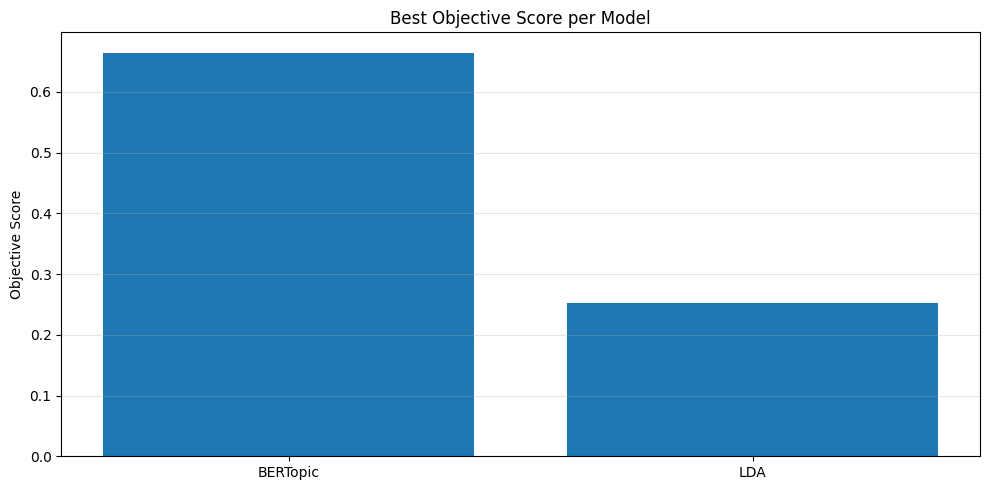

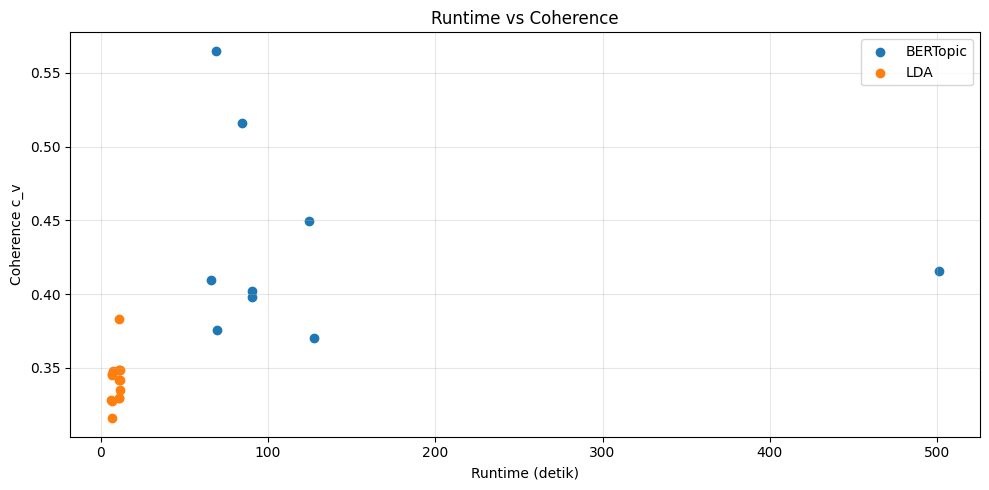

In [13]:
def get_ok_rows(df):
    if df.empty:
        return df
    return df[df["status"] == "ok"].copy()


bertopic_ok = get_ok_rows(bertopic_results_df)
lda_ok = get_ok_rows(lda_results_df)

best_model_rows = []

if not bertopic_ok.empty:
    b = bertopic_ok.iloc[0]
    best_model_rows.append(
        {
            "model": "BERTopic",
            "best_scenario": b["scenario_id"],
            "objective_score": b.get("objective_score"),
            "coherence_cv": b.get("coherence_cv"),
            "topic_diversity": b.get("topic_diversity"),
            "runtime_seconds": b.get("runtime_seconds"),
            "num_topics": b.get("num_topics"),
        }
    )

if not lda_ok.empty:
    l = lda_ok.iloc[0]
    best_model_rows.append(
        {
            "model": "LDA",
            "best_scenario": l["scenario_id"],
            "objective_score": l.get("objective_score"),
            "coherence_cv": l.get("coherence_cv"),
            "topic_diversity": l.get("topic_diversity"),
            "runtime_seconds": l.get("runtime_seconds"),
            "num_topics": l.get("num_topics"),
        }
    )

best_model_df = pd.DataFrame(best_model_rows)
display(best_model_df)

leaderboard_parts = []
if not bertopic_ok.empty:
    tmp_b = bertopic_ok.copy()
    tmp_b["model"] = "BERTopic"
    leaderboard_parts.append(tmp_b)

if not lda_ok.empty:
    tmp_l = lda_ok.copy()
    tmp_l["model"] = "LDA"
    leaderboard_parts.append(tmp_l)

if leaderboard_parts:
    leaderboard_df = pd.concat(leaderboard_parts, ignore_index=True)

    numeric_cols = ["coherence_cv", "topic_diversity", "runtime_seconds", "objective_score"]
    for col in numeric_cols:
        if col in leaderboard_df.columns:
            leaderboard_df[col] = pd.to_numeric(leaderboard_df[col], errors="coerce")

    norm_df = leaderboard_df.copy()
    for col in ["coherence_cv", "topic_diversity", "runtime_seconds"]:
        if col not in norm_df.columns:
            continue
        cmin = norm_df[col].min()
        cmax = norm_df[col].max()
        if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
            norm_df[col + "_norm"] = 0.5
        else:
            norm_df[col + "_norm"] = (norm_df[col] - cmin) / (cmax - cmin)

    if "runtime_seconds_norm" in norm_df.columns:
        norm_df["runtime_seconds_norm"] = 1 - norm_df["runtime_seconds_norm"]

    norm_df["pareto_score"] = (
        0.45 * norm_df.get("coherence_cv_norm", 0.5)
        + 0.35 * norm_df.get("topic_diversity_norm", 0.5)
        + 0.20 * norm_df.get("runtime_seconds_norm", 0.5)
    )

    norm_df = norm_df.sort_values("pareto_score", ascending=False).reset_index(drop=True)
    display(norm_df[["model", "scenario_id", "objective_score", "coherence_cv", "topic_diversity", "runtime_seconds", "pareto_score"]].head(20))

    plt.figure(figsize=(10, 5))
    if sns is not None:
        sns.barplot(data=best_model_df, x="model", y="objective_score")
    else:
        plt.bar(best_model_df["model"], best_model_df["objective_score"])
    plt.title("Best Objective Score per Model")
    plt.ylabel("Objective Score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    if sns is not None:
        sns.scatterplot(data=norm_df, x="runtime_seconds", y="coherence_cv", hue="model")
    else:
        for model_name in norm_df["model"].dropna().unique():
            subset = norm_df[norm_df["model"] == model_name]
            plt.scatter(subset["runtime_seconds"], subset["coherence_cv"], label=model_name)
        plt.legend()
    plt.title("Runtime vs Coherence")
    plt.xlabel("Runtime (detik)")
    plt.ylabel("Coherence c_v")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    leaderboard_df = pd.DataFrame()
    norm_df = pd.DataFrame()
    print("Belum ada hasil sukses untuk dibandingkan.")

## 10. Simpan Best Config, Model, dan Tabel Hasil ke Folder fastAPI
Simpan leaderboard tuning ke CSV/parquet, best config ke JSON, dan model terbaik. Jika path default model tidak writable, notebook otomatis fallback ke `data/results/artifacts_tuning/saved_models`.

In [15]:
run_ts = datetime.now().strftime("%Y%m%d-%H%M%S")

bertopic_csv_path = ARTIFACTS_DIR / f"bertopic_tuning_{run_ts}.csv"
lda_csv_path = ARTIFACTS_DIR / f"lda_tuning_{run_ts}.csv"
combined_csv_path = ARTIFACTS_DIR / f"combined_leaderboard_{run_ts}.csv"
combined_parquet_path = ARTIFACTS_DIR / f"combined_leaderboard_{run_ts}.parquet"
best_config_path = ARTIFACTS_DIR / f"best_config_{run_ts}.json"
best_model_path = ARTIFACTS_DIR / f"best_model_paths_{run_ts}.json"
fallback_models_dir = ARTIFACTS_DIR / "saved_models"
fallback_models_dir.mkdir(parents=True, exist_ok=True)


def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def write_json(path: Path, payload: dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)


def save_bertopic_with_fallback(trainer, job_id: str) -> str:
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = fallback_models_dir / f"bertopic_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        model_path = str(fallback_dir / "model")
        trainer.model.save(model_path, serialization="safetensors", save_ctfidf=True)

        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(fallback_dir / "embeddings.npy"), trainer.embeddings)

        metadata = {
            "job_id": job_id,
            "model_type": "bertopic",
            "save_mode": "fallback_notebook",
            "reason": str(exc),
            "saved_at": datetime.now().isoformat(),
            "hyperparameters": trainer.params.model_dump(),
        }
        write_json(fallback_dir / "metadata.json", metadata)

        print(f"[WARN] Gagal simpan BERTopic ke path default. Fallback ke: {fallback_dir}")
        return str(fallback_dir)


def save_lda_with_fallback(trainer, job_id: str) -> str:
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = fallback_models_dir / f"lda_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)

        trainer.model.save(str(fallback_dir / "lda_model"))
        trainer.dictionary.save(str(fallback_dir / "dictionary.dict"))

        metadata = {
            "job_id": job_id,
            "model_type": "lda",
            "save_mode": "fallback_notebook",
            "reason": str(exc),
            "saved_at": datetime.now().isoformat(),
            "hyperparameters": trainer.params.model_dump(),
        }
        write_json(fallback_dir / "metadata.json", metadata)

        print(f"[WARN] Gagal simpan LDA ke path default. Fallback ke: {fallback_dir}")
        return str(fallback_dir)


bertopic_results_df.to_csv(bertopic_csv_path, index=False)
lda_results_df.to_csv(lda_csv_path, index=False)

if not leaderboard_df.empty:
    leaderboard_df.to_csv(combined_csv_path, index=False)
    try:
        leaderboard_df.to_parquet(combined_parquet_path, index=False)
        parquet_saved = True
    except Exception as parquet_exc:
        parquet_saved = False
        print("Simpan parquet dilewati:", parquet_exc)
else:
    parquet_saved = False

best_config_payload = {
    "timestamp": run_ts,
    "best_bertopic": None,
    "best_lda": None,
}

if best_bertopic_payload is not None:
    best_config_payload["best_bertopic"] = {
        "scenario_id": best_bertopic_payload["scenario"]["scenario_id"],
        "params": best_bertopic_payload["scenario"]["params"].model_dump(),
        "metrics": best_bertopic_payload["metrics"],
    }

if best_lda_payload is not None:
    best_config_payload["best_lda"] = {
        "scenario_id": best_lda_payload["scenario"]["scenario_id"],
        "params": best_lda_payload["scenario"]["params"].model_dump(),
        "metrics": best_lda_payload["metrics"],
    }

write_json(best_config_path, best_config_payload)

saved_model_paths = {"bertopic": None, "lda": None}

if best_bertopic_payload is not None:
    bertopic_job_id = f"nb_best_bertopic_{run_ts}"
    saved_model_paths["bertopic"] = save_bertopic_with_fallback(best_bertopic_payload["trainer"], bertopic_job_id)

if best_lda_payload is not None:
    lda_job_id = f"nb_best_lda_{run_ts}"
    saved_model_paths["lda"] = save_lda_with_fallback(best_lda_payload["trainer"], lda_job_id)

write_json(best_model_path, saved_model_paths)

print("Artifacts tersimpan:")
print("-", bertopic_csv_path)
print("-", lda_csv_path)
if not leaderboard_df.empty:
    print("-", combined_csv_path)
if parquet_saved:
    print("-", combined_parquet_path)
print("-", best_config_path)
print("-", best_model_path)
print("Fallback model dir:", fallback_models_dir)
print("Model storage path:", saved_model_paths)

Simpan parquet dilewati: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
[WARN] Gagal simpan BERTopic ke path default. Fallback ke: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/artifacts_tuning/saved_models/bertopic_nb_best_bertopic_20260410-035246
[WARN] Gagal simpan LDA ke path default. Fallback ke: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/artifacts_tuning/saved_models/lda_nb_best_lda_20260410-035246
Artifacts tersimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/artifacts_tuning/bertopic_tuning_20260410-035246.csv
- /

## 11. Uji Inference Singkat dengan Model Terbaik
Lakukan prediksi topik pada beberapa teks contoh untuk validasi cepat sebelum integrasi ke website.

In [19]:
sample_texts = [
    "Sistem rekomendasi berbasis machine learning untuk pemilihan topik skripsi mahasiswa.",
    "Implementasi website monitoring kualitas udara menggunakan sensor IoT dan dashboard interaktif.",
    "Perbandingan performa model deep learning untuk klasifikasi sentimen bahasa Indonesia.",
]

if best_bertopic_payload is None and best_lda_payload is None:
    print("Belum ada model terbaik yang bisa diuji inference.")

if best_bertopic_payload is not None:
    best_bertopic_model = best_bertopic_payload["trainer"].model
    bertopic_inputs = [preprocessor.preprocess_cleaned(t) for t in sample_texts]
    raw_topics, _ = best_bertopic_model.transform(bertopic_inputs)
    raw_topics = [int(t) for t in raw_topics]

    adjusted_topics = raw_topics.copy()
    fallback_methods = ["direct_transform"] * len(adjusted_topics)

    if any(t == -1 for t in adjusted_topics):
        try:
            reduced = best_bertopic_model.reduce_outliers(
                bertopic_inputs,
                adjusted_topics,
                strategy="distributions",
            )
            reduced = [int(t) for t in reduced]
            for i, (before_t, after_t) in enumerate(zip(adjusted_topics, reduced)):
                if before_t == -1 and after_t != -1:
                    fallback_methods[i] = "reduce_outliers_distributions"
            adjusted_topics = reduced
        except Exception as exc:
            if "No outliers to reduce" not in str(exc):
                print("[WARN] reduce_outliers(distributions) gagal:", exc)

    if any(t == -1 for t in adjusted_topics):
        try:
            reduced = best_bertopic_model.reduce_outliers(
                bertopic_inputs,
                adjusted_topics,
                strategy="embeddings",
            )
            reduced = [int(t) for t in reduced]
            for i, (before_t, after_t) in enumerate(zip(adjusted_topics, reduced)):
                if before_t == -1 and after_t != -1:
                    fallback_methods[i] = "reduce_outliers_embeddings"
            adjusted_topics = reduced
        except Exception as exc:
            if "No outliers to reduce" not in str(exc):
                print("[WARN] reduce_outliers(embeddings) gagal:", exc)

    bertopic_infer_rows = []
    for text, query_text, raw_topic_id, topic_id, method in zip(
        sample_texts,
        bertopic_inputs,
        raw_topics,
        adjusted_topics,
        fallback_methods,
    ):
        topic_id = int(topic_id)
        fallback_score = None

        if topic_id == -1:
            try:
                candidate_topics, candidate_scores = best_bertopic_model.find_topics(query_text, top_n=1)
                if candidate_topics:
                    topic_id = int(candidate_topics[0])
                    fallback_score = float(candidate_scores[0]) if candidate_scores else None
                    method = "find_topics_fallback"
            except Exception as exc:
                print("[WARN] find_topics fallback gagal:", exc)

        if topic_id == -1:
            top_words = "outlier"
        else:
            topic_words = best_bertopic_model.get_topic(topic_id) or []
            top_words = ", ".join([w for w, _ in topic_words[:5]]) if topic_words else "(topic kosong)"

        bertopic_infer_rows.append(
            {
                "text": text,
                "raw_pred_topic_id": int(raw_topic_id),
                "final_pred_topic_id": int(topic_id),
                "was_outlier_raw": int(raw_topic_id) == -1,
                "fallback_method": method,
                "fallback_score": None if fallback_score is None else round(fallback_score, 4),
                "top_words": top_words,
            }
        )

    raw_outliers = sum(1 for t in raw_topics if int(t) == -1)
    unresolved_after_fallback = sum(1 for row in bertopic_infer_rows if int(row["final_pred_topic_id"]) == -1)
    print(
        f"Inference BERTopic: raw_outliers={raw_outliers}, unresolved_after_fallback={unresolved_after_fallback}"
    )
    display(pd.DataFrame(bertopic_infer_rows))

if best_lda_payload is not None:
    best_lda_trainer = best_lda_payload["trainer"]
    lda_inputs = [preprocessor.preprocess(t) for t in sample_texts]
    lda_tokens = [text.split() for text in lda_inputs]
    lda_bows = [best_lda_trainer.dictionary.doc2bow(tokens) for tokens in lda_tokens]

    lda_infer_rows = []
    for raw_text, bow in zip(sample_texts, lda_bows):
        distribution = best_lda_trainer.model.get_document_topics(bow, minimum_probability=0.0)
        top_topic, top_prob = max(distribution, key=lambda x: x[1])
        top_words = ", ".join([w for w, _ in best_lda_trainer.model.show_topic(top_topic, topn=5)])

        lda_infer_rows.append(
            {
                "text": raw_text,
                "pred_topic_id": int(top_topic),
                "topic_probability": round(float(top_prob), 4),
                "top_words": top_words,
            }
        )

    print("Inference LDA:")
    display(pd.DataFrame(lda_infer_rows))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]
2026-04-10 03:58:02,577 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-10 03:58:02,644 - BERTopic - Dimensionality - Completed ✓
2026-04-10 03:58:02,645 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-10 03:58:02,647 - BERTopic - Cluster - Completed ✓


Inference BERTopic: raw_outliers=3, unresolved_after_fallback=0


,text,raw_pred_topic_id,final_pred_topic_id,was_outlier_raw,fallback_method,fallback_score,top_words
0,Sistem rekomendasi berbasis machine learning u...,-1,1,True,find_topics_fallback,0.4333,"algoritma, analisis, pengujian, terbaik, imple..."
1,Implementasi website monitoring kualitas udara...,-1,1,True,find_topics_fallback,0.5093,"algoritma, analisis, pengujian, terbaik, imple..."
2,Perbandingan performa model deep learning untu...,-1,4,True,find_topics_fallback,0.4376,"performa, laravel, pengujian, server, analisis"


Inference LDA:


,text,pred_topic_id,topic_probability,top_words
0,Sistem rekomendasi berbasis machine learning u...,0,0.5584,"model, nilai, siswa, aplikasi, tingkat"
1,Implementasi website monitoring kualitas udara...,7,0.8748,"tingkat, implementasi, aplikasi, fitur, integrasi"
2,Perbandingan performa model deep learning untu...,0,0.7168,"model, nilai, siswa, aplikasi, tingkat"
